# 📊 Exploration des Données - Détection de Pneumonie

Dataset: [raw_pneumonia_x_ray](https://huggingface.co/datasets/mmenendezg/raw_pneumonia_x_ray)

**Objectif:** Comprendre la structure, distribution et qualité des données avant entraînement.

## 1. Chargement du Dataset

In [1]:
import sys
sys.path.append('..')  # Pour importer depuis src/

from src.data_loader import load_raw_pneumonia_dataset
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

/Users/taoufik/CLassification/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Charger le dataset
dataset = load_raw_pneumonia_dataset("train")
print(f"✅ Dataset chargé: {len(dataset)} images")
print(f"📋 Colonnes: {dataset.column_names}")

✅ Dataset chargé: 5232 images
📋 Colonnes: ['image', 'label']


## 2. Distribution des Classes

In [3]:
# Compter les classes
labels = dataset['label']
class_counts = Counter(labels)

print("Distribution:")
for cls, count in class_counts.items():
    percentage = (count / len(dataset)) * 100
    class_name = "Sain" if cls == 0 else "Pneumonie"
    print(f"  Classe {cls} ({class_name}): {count} images ({percentage:.1f}%)")

Distribution:
  Classe 0 (Sain): 1349 images (25.8%)
  Classe 1 (Pneumonie): 3883 images (74.2%)


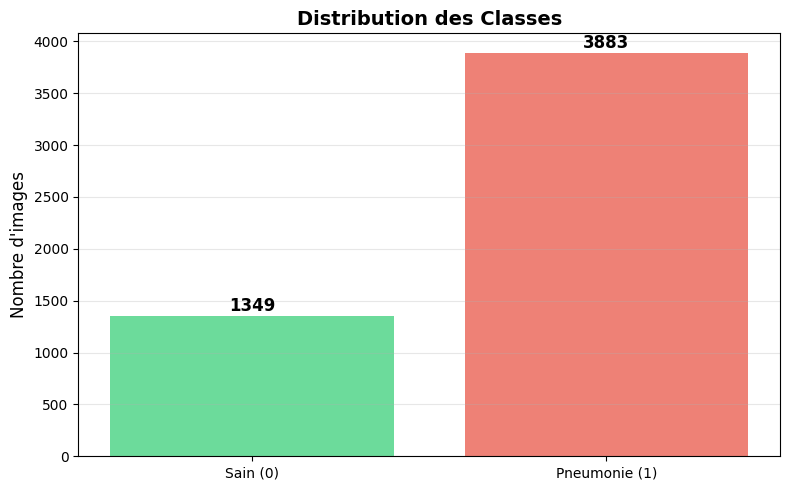

In [4]:
# Visualiser la distribution
fig, ax = plt.subplots(figsize=(8, 5))
classes = ['Sain (0)', 'Pneumonie (1)']
counts = [class_counts[0], class_counts[1]]
colors = ['#2ecc71', '#e74c3c']

ax.bar(classes, counts, color=colors, alpha=0.7)
ax.set_ylabel('Nombre d\'images', fontsize=12)
ax.set_title('Distribution des Classes', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, count in enumerate(counts):
    ax.text(i, count + 50, str(count), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Visualisation des Images

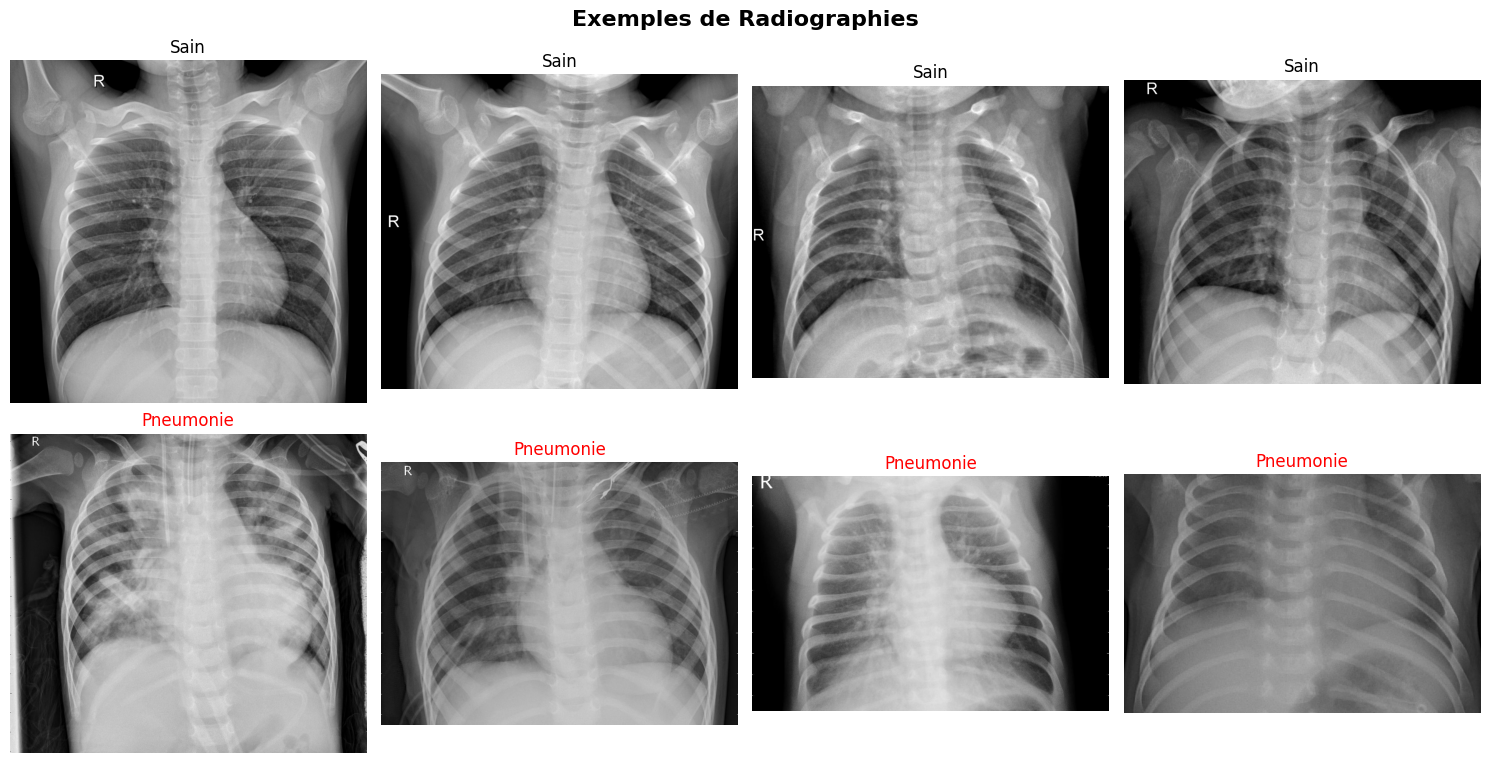

In [5]:
# Afficher des exemples de chaque classe
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
fig.suptitle('Exemples de Radiographies', fontsize=16, fontweight='bold')

# Classe 0 (Sain)
healthy_indices = [i for i, label in enumerate(dataset['label']) if label == 0][:4]
for i, idx in enumerate(healthy_indices):
    img = dataset[idx]['image']
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title('Sain', fontsize=12)
    axes[0, i].axis('off')

# Classe 1 (Pneumonie)
pneumo_indices = [i for i, label in enumerate(dataset['label']) if label == 1][:4]
for i, idx in enumerate(pneumo_indices):
    img = dataset[idx]['image']
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title('Pneumonie', fontsize=12, color='red')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 4. Analyse des Dimensions

In [6]:
# Vérifier les dimensions des images
sample_images = [dataset[i]['image'] for i in range(min(100, len(dataset)))]
dimensions = [img.size for img in sample_images]  # (width, height)

unique_dims = set(dimensions)
print(f"Dimensions uniques trouvées: {len(unique_dims)}")
print(f"Exemples: {list(unique_dims)[:5]}")

# Dimensions les plus fréquentes
dim_counter = Counter(dimensions)
print("\nDimensions les plus fréquentes:")
for dim, count in dim_counter.most_common(5):
    print(f"  {dim[0]}x{dim[1]}: {count} images")

Dimensions uniques trouvées: 99
Exemples: [(1750, 1314), (1608, 1468), (1716, 1504), (1426, 1128), (1466, 1265)]

Dimensions les plus fréquentes:
  1962x2169: 2 images
  2572x2476: 1 images
  1982x1751: 1 images
  1236x1013: 1 images
  1414x1206: 1 images


## 5. Conclusions de l'EDA

**Points clés à retenir:**
- Déséquilibre des classes → Besoin de class weights ou data augmentation
- Dimensions variables → Besoin de redimensionnement uniforme
- Images en niveaux de gris → 1 canal d'entrée